In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [13]:
# univariate statistics
max_steps = 100000
step_size = 1000

ts = [x * step_size for x in range(1, int(max_steps/step_size) + 1)]

In [14]:
df = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_0_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_0_{t}.csv")
    df = pd.concat([df, dftemp], ignore_index=True)

In [15]:
con_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_blackpercs.append(tempvotes[s,:])

con_blackpercs = pd.DataFrame(con_blackpercs)

medianprops = dict(color='black')

c_con="tab:blue"

In [16]:
len(df)

99999

In [35]:
rep_df = con_blackpercs[df["DWins"] == 3]
c = "tab:red"

C:\Users\angel\AppData\Local\Temp\ipykernel_31072\3844582868.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rep_df = con_blackpercs[df["DWins"] == 3]


In [36]:
len(rep_df)

814

Text(0.5, 1.0, 'NC Districts % Black, 3 D Seats')

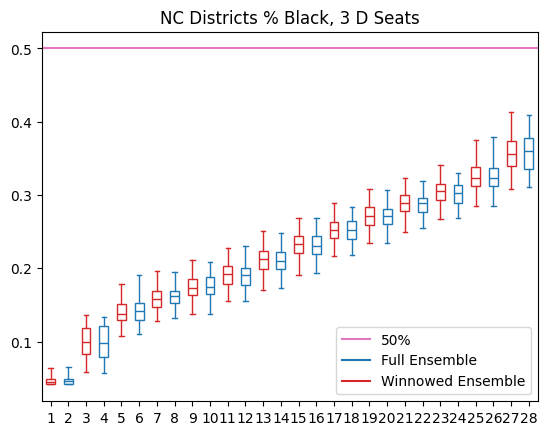

In [37]:
plt.boxplot(
    con_blackpercs,
    positions=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c,markeredgecolor=c),
    medianprops=dict(color=c)
)

plt.boxplot(
    rep_df,
    positions=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

"""plt.plot(,sorted([0.1828165961087225,
 0.18492617005629175,
 0.19797997475993911,
 0.25449946333226225,
 0.2663038733124516,
 0.2726958300124814,
 0.4819280068798886]),"*",color="k",label="Enacted")"""

plt.plot([0.5,28.5],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='Full Ensemble')
plt.plot([],[],color='tab:red',label='Winnowed Ensemble')
plt.legend()
plt.title("NC Districts % Black, 3 D Seats")